In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/ev_sales_india.csv")
df.head()

,Year,Month_Name,Date,State,Vehicle_Class,Vehicle_Category,Vehicle_Type,EV_Sales_Quantity
0,2014.0,jan,1/1/2014,Andhra Pradesh,ADAPTED VEHICLE,Others,Others,0.0
1,2014.0,jan,1/1/2014,Andhra Pradesh,AGRICULTURAL TRACTOR,Others,Others,0.0
2,2014.0,jan,1/1/2014,Andhra Pradesh,AMBULANCE,Others,Others,0.0
3,2014.0,jan,1/1/2014,Andhra Pradesh,ARTICULATED VEHICLE,Others,Others,0.0
4,2014.0,jan,1/1/2014,Andhra Pradesh,BUS,Bus,Bus,0.0


In [3]:
df.describe()

,Year,EV_Sales_Quantity
count,96845.000000,96845.000000
mean,2018.622768,37.108896
std,2.895581,431.566675
min,2014.000000,0.000000
25%,2016.000000,0.000000
50%,2019.000000,0.000000
75%,2021.000000,0.000000
max,2024.000000,20584.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96845 entries, 0 to 96844
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Year               96845 non-null  float64
 1   Month_Name         96845 non-null  object 
 2   Date               96845 non-null  object 
 3   State              96845 non-null  object 
 4   Vehicle_Class      96845 non-null  object 
 5   Vehicle_Category   96845 non-null  object 
 6   Vehicle_Type       96845 non-null  object 
 7   EV_Sales_Quantity  96845 non-null  float64
dtypes: float64(2), object(6)
memory usage: 5.9+ MB


In [5]:
df.isnull().sum()

Year                 0
Month_Name           0
Date                 0
State                0
Vehicle_Class        0
Vehicle_Category     0
Vehicle_Type         0
EV_Sales_Quantity    0
dtype: int64

## EDA analysis

In [7]:
top_states = (
    df.groupby("State")["EV_Sales_Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

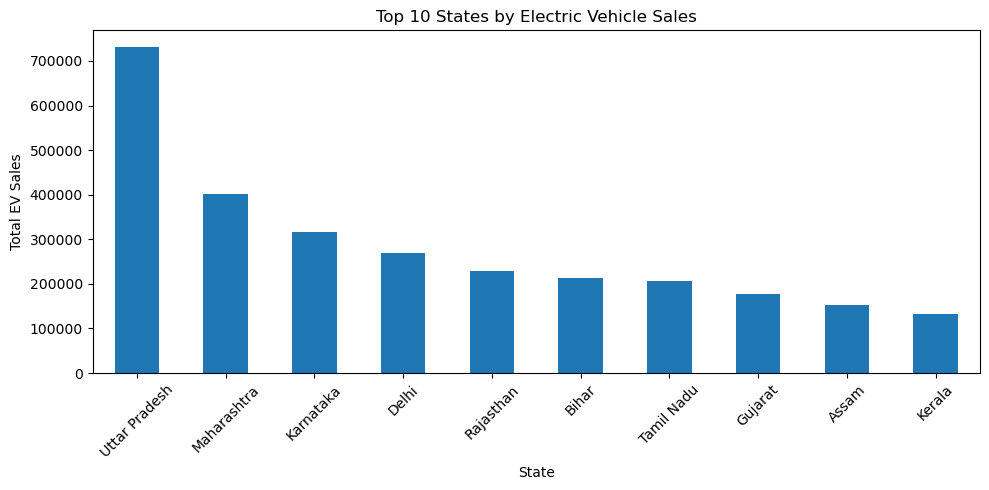

In [8]:
plt.figure(figsize=(10, 5))
top_states.plot(kind="bar")
plt.title("Top 10 States by Electric Vehicle Sales")
plt.xlabel("State")
plt.ylabel("Total EV Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:
yearly_sales = (
    df.groupby("Year")["EV_Sales_Quantity"]
    .sum()
)

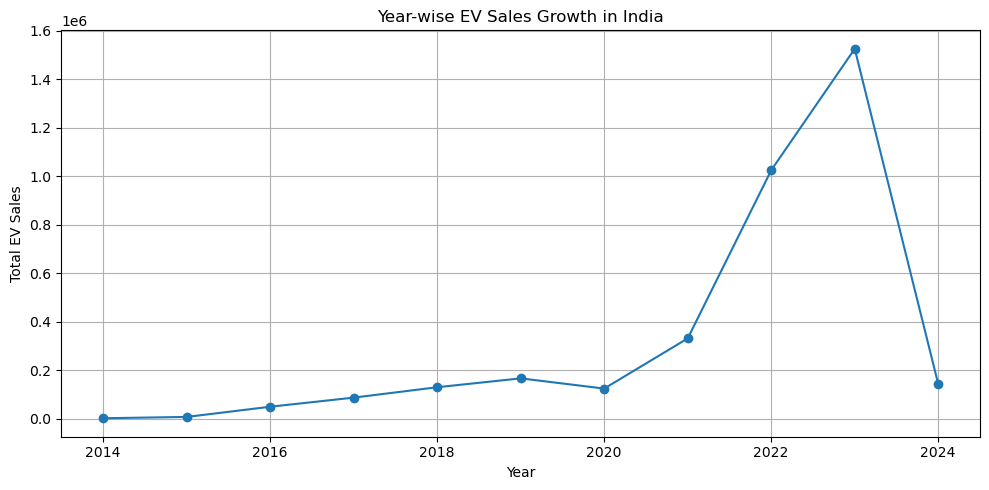

In [10]:
plt.figure(figsize=(10, 5))
plt.plot(yearly_sales.index, yearly_sales.values, marker='o')
plt.title("Year-wise EV Sales Growth in India")
plt.xlabel("Year")
plt.ylabel("Total EV Sales")
plt.grid(True)
plt.tight_layout()
plt.show()

In [11]:
ev_type_sales = (
    df.groupby("Vehicle_Type")["EV_Sales_Quantity"]
    .sum()
)

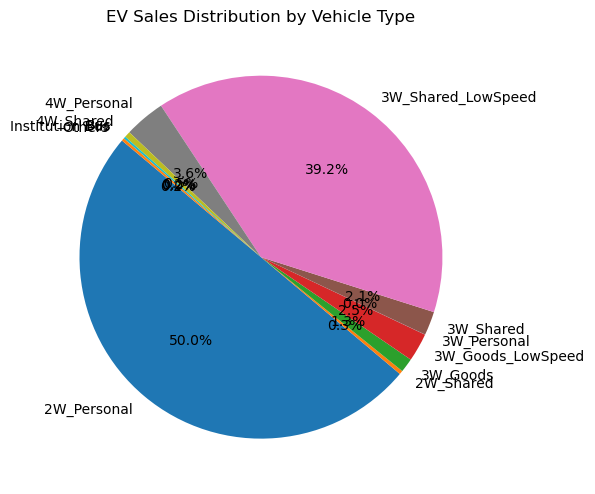

In [12]:
plt.figure(figsize=(6, 6))
plt.pie(
    ev_type_sales,
    labels=ev_type_sales.index,
    autopct='%1.1f%%',
    startangle=140
)
plt.title("EV Sales Distribution by Vehicle Type")
plt.tight_layout()
plt.show()

In [13]:
plt.savefig("../outputs/top_10_states_ev_sales.png")
plt.savefig("../outputs/yearly_ev_sales_growth.png")
plt.savefig("../outputs/ev_sales_distribution_by_type.png")

<Figure size 640x480 with 0 Axes>